# Portafolio Cuantitativo Neutral al Mercado

## Extensión: Validación Walk-Forward (Múltiples Ventanas de Tiempo)

**Autor:** Samuel

**Institución:** Tec de Monterrey

**Área:** Finanzas Cuantitativas, Economía Estadística y Machine Learning

**Notebooks previos:** `main.ipynb`, `RMT+TDA.ipynb`, `K-D.ipynb`

---

Hasta ahora, todo el pipeline (RMT → TDA → cointegración → Kalman dinámico → backtest) se validó con un **único** corte 70/30: una ventana de entrenamiento y una de prueba. `K-D.ipynb` dio un resultado positivo (P&L neto +0.2385, win-rate 88.7%), pero no sabemos si ese resultado depende de haber elegido justo esa ventana de tiempo, o si es un comportamiento que se repite de forma consistente en distintos periodos.

Este notebook responde esa pregunta mediante **walk-forward validation**: en vez de un solo corte, se repite el proceso completo (encontrar la canasta cointegrada vía RMT+TDA, calibrar el Kalman dinámico, correr el backtest) sobre varias ventanas consecutivas de tiempo, deslizando hacia adelante. El objetivo no es maximizar ningún número — es entender **en qué ventanas funciona, en cuáles no, y qué tan estable es el resultado de `K-D.ipynb`** antes de reportarlo como un hallazgo confiable.

Como consecuencia de este diseño, el universo de divisas y la canasta encontrada **podrían cambiar entre ventanas** (RMT+TDA se re-ejecuta en cada una) — eso es intencional, no un error: parte de lo que queremos observar es si el mismo cluster (JPY, SEK, NOK, SGD) sigue apareciendo consistentemente, o si distintas ventanas encuentran relaciones distintas.

## Estructura de este Notebook

1. **Instalación de librerías** — mismas de los notebooks anteriores (yfinance, statsmodels, gudhi/ripser/kmapper, pykalman, hmmlearn, quantstats).
2. **Fase 1: Datos de mayor cobertura** — a diferencia de los notebooks anteriores, aquí se necesita suficiente historia para poder cortarla en varias ventanas — se revisa si los ~729 días de yfinance alcanzan o si conviene ampliar la fuente.
3. **Fase 2: Definición de las ventanas walk-forward** — *nueva*. Se define el esquema de corte (tamaño de la ventana de entrenamiento, tamaño del tramo de prueba, y cuánto se desliza entre una ventana y la siguiente).
4. **Fase 3: Pipeline encapsulado en una función** — *nueva*. Se empaqueta todo lo aprendido en `RMT+TDA.ipynb` y `K-D.ipynb` (selección de canasta + Kalman dinámico + backtest) en una sola función reutilizable, para poder correrla una vez por cada ventana sin repetir código a mano.
5. **Fase 4: Ejecución sobre todas las ventanas** — se corre la función de la Fase 3 en cada ventana y se recopilan los resultados (canasta encontrada, P&L, win-rate, Sharpe, etc. por ventana).
6. **Fase 5: Análisis de consistencia** — comparación de resultados entre ventanas: ¿qué tan seguido se repite el mismo cluster? ¿el P&L es consistentemente positivo o varía mucho? ¿hay ventanas claramente malas, y coinciden con algún periodo identificable?
7. **Conclusión** — veredicto sobre si `K-D.ipynb` es un resultado robusto o específico de esa ventana.

## Instalación de Librerías

Mismas librerías que `RMT+TDA.ipynb` y `K-D.ipynb` — nada nuevo en este notebook, ya que reutilizamos ese pipeline completo dentro de un loop.

In [3]:
# %pip install yfinance pandas numpy
# %pip install scipy gudhi ripser kmapper scikit-learn
# %pip install networkx statsmodels pykalman hmmlearn quantstats

## Fase 1: Datos

Se descargan los ~729 días de datos horarios, igual que en los notebooks anteriores. La diferencia aquí es que **no se hace un único split 70/30** — el corte en ventanas de entrenamiento/prueba se define en la Fase 2, y se aplica repetidamente sobre esta misma serie completa.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
pd.set_option('display.max_columns', None)

tickers = {
    'EURUSD': 'EURUSD=X', 'GBPUSD': 'GBPUSD=X', 'AUDUSD': 'AUDUSD=X', 'NZDUSD': 'NZDUSD=X',
    'USDJPY': 'USDJPY=X', 'USDCAD': 'USDCAD=X', 'USDCHF': 'USDCHF=X', 'USDMXN': 'USDMXN=X',
    'USDCNY': 'USDCNY=X', 'USDSEK': 'USDSEK=X', 'USDNOK': 'USDNOK=X', 'USDSGD': 'USDSGD=X',
}

raw_data = yf.download(list(tickers.values()), period='729d', interval='60m', progress=False)['Close']
raw_data.columns = tickers.keys()

data = raw_data.copy().ffill().dropna()

print(f"data: {data.shape}")
print(f"Rango completo: {data.index.min()} a {data.index.max()}")

data: (17347, 12)
Rango completo: 2023-12-14 01:00:00+00:00 a 2026-09-29 19:00:00+01:00


## Fase 2: Definición de las Ventanas Walk-Forward

Se divide la serie completa en ventanas consecutivas de entrenamiento + prueba, deslizando hacia adelante. Con ~729 días totales, cada ventana necesariamente será más corta que el split único que usamos antes — el objetivo ya no es maximizar el tamaño de una sola muestra, sino observar el comportamiento en varios periodos independientes.

Esquema elegido: ventanas de entrenamiento de 120 días (~4 meses) y prueba de 30 días (~1 mes), deslizando 30 días entre una ventana y la siguiente (sin traslape en los tramos de prueba, para que cada resultado de test sea sobre datos genuinamente distintos). Con esto, de los ~729 días disponibles se obtienen aproximadamente 12-13 ventanas.

In [6]:
def generate_walk_forward_windows(data: pd.DataFrame, train_days: int = 120, test_days: int = 30, step_days: int = 30):
    """
    Genera una lista de (train, test) deslizando en el tiempo.
    Los días se convierten a número de observaciones asumiendo ~24 velas/día (aproximado, Forex 24/5).
    """
    obs_per_day = 24
    train_size = train_days * obs_per_day
    test_size = test_days * obs_per_day
    step_size = step_days * obs_per_day

    windows = []
    start = 0
    while start + train_size + test_size <= len(data):
        train_window = data.iloc[start : start + train_size]
        test_window = data.iloc[start + train_size : start + train_size + test_size]
        windows.append((train_window, test_window))
        start += step_size

    return windows

windows = generate_walk_forward_windows(data, train_days=120, test_days=30, step_days=30)

print(f"Número de ventanas generadas: {len(windows)}")
for i, (tr, te) in enumerate(windows):
    print(f"Ventana {i}: train {tr.index.min().date()} a {tr.index.max().date()} "
          f"({len(tr)} obs) | test {te.index.min().date()} a {te.index.max().date()} ({len(te)} obs)")

Número de ventanas generadas: 20
Ventana 0: train 2023-12-14 a 2024-05-30 (2880 obs) | test 2024-05-30 a 2024-07-11 (720 obs)
Ventana 1: train 2024-01-25 a 2024-07-11 (2880 obs) | test 2024-07-11 a 2024-08-23 (720 obs)
Ventana 2: train 2024-03-07 a 2024-08-23 (2880 obs) | test 2024-08-23 a 2024-10-04 (720 obs)
Ventana 3: train 2024-04-18 a 2024-10-04 (2880 obs) | test 2024-10-04 a 2024-11-15 (720 obs)
Ventana 4: train 2024-05-30 a 2024-11-15 (2880 obs) | test 2024-11-15 a 2024-12-27 (720 obs)
Ventana 5: train 2024-07-11 a 2024-12-27 (2880 obs) | test 2024-12-27 a 2025-02-07 (720 obs)
Ventana 6: train 2024-08-23 a 2025-02-07 (2880 obs) | test 2025-02-07 a 2025-03-24 (720 obs)
Ventana 7: train 2024-10-04 a 2025-03-24 (2880 obs) | test 2025-03-24 a 2025-05-05 (720 obs)
Ventana 8: train 2024-11-15 a 2025-05-05 (2880 obs) | test 2025-05-05 a 2025-06-16 (720 obs)
Ventana 9: train 2024-12-27 a 2025-06-16 (2880 obs) | test 2025-06-16 a 2025-07-28 (720 obs)
Ventana 10: train 2025-02-07 a 2025-0

## Fase 3: Pipeline Encapsulado en una Función

Se empaqueta todo lo construido en `RMT+TDA.ipynb` y `K-D.ipynb` (limpieza RMT → clustering TDA → validación econométrica → selección automática de la mejor canasta → Kalman dinámico → reglas + HMM → backtest) en una sola función, para poder correrla una vez por cada una de las 20 ventanas sin repetir código a mano.

**Un cambio importante frente a los notebooks anteriores:** ahí elegimos el Cluster 3 nosotros mismos, viendo las tablas. Aquí necesitamos una **regla automática** de selección, porque no vamos a revisar 20 tablas a mano. La regla: se prefiere una canasta de 3+ divisas cuya relación de Johansen aparezca en al menos 3 de 4 rezagos probados (robustez, como vimos con JPY/SEK/NOK/SGD); si ninguna canasta califica, se acepta un par de Engle-Granger que sobreviva Bonferroni sobre el número real de pares probados en esa ventana; si nada califica, la ventana queda marcada como "sin candidato" — un resultado válido en sí mismo, no un error.

In [7]:
from scipy import linalg
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from itertools import combinations
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.multitest import multipletests
from numpy.linalg import lstsq
from pykalman import KalmanFilter
from hmmlearn.hmm import GaussianHMM
import gudhi


In [8]:
def clean_correlation_rmt(log_returns: pd.DataFrame) -> pd.DataFrame:
    N, T = log_returns.shape[1], log_returns.shape[0]
    Q = T / N
    corr = log_returns.corr()
    eigenvalues, eigenvectors = linalg.eigh(corr.values)
    eigenvalues, eigenvectors = eigenvalues[::-1], eigenvectors[:, ::-1]
    lambda_plus = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = (eigenvalues > lambda_plus).sum()
    cleaned = eigenvalues.copy()
    if n_signal < len(eigenvalues):
        cleaned[n_signal:] = eigenvalues[n_signal:].mean()
    corr_clean = eigenvectors @ np.diag(cleaned) @ eigenvectors.T
    d = np.sqrt(np.diag(corr_clean))
    corr_clean = corr_clean / np.outer(d, d)
    return pd.DataFrame(corr_clean, index=corr.index, columns=corr.columns)


def tda_clusters(corr_clean: pd.DataFrame, cut_height: float = 1.0) -> dict:
    distance_matrix = np.sqrt(2 * (1 - corr_clean.values))
    np.fill_diagonal(distance_matrix, 0)
    condensed = squareform(distance_matrix, checks=False)
    Z = linkage(condensed, method='average')
    labels = fcluster(Z, t=cut_height, criterion='distance')
    clusters_df = pd.DataFrame({'divisa': corr_clean.columns, 'cluster': labels})
    return clusters_df.groupby('cluster')['divisa'].apply(list).to_dict()


def johansen_relations(log_prices: pd.DataFrame, lags=(1, 4, 12, 24)) -> float:
    """Fracción de rezagos en los que Johansen detecta al menos 1 relación."""
    hits = 0
    for lag in lags:
        try:
            result = coint_johansen(log_prices, det_order=0, k_ar_diff=lag)
            if (result.lr1 > result.cvt[:, 1]).sum() > 0:
                hits += 1
        except Exception:
            continue
    return hits / len(lags)


def select_best_basket(train_prices: pd.DataFrame, clusters: dict, robust_threshold: float = 0.75):
    """Aplica la regla de selección automática descrita en el markdown de la fase."""
    log_train = np.log(train_prices)

    # 1. Buscar canastas robustas (3+ divisas) vía Johansen
    basket_candidates = []
    for cid, members in clusters.items():
        if len(members) < 3:
            continue
        score = johansen_relations(log_train[members], lags=(1, 4, 12, 24))
        if score >= robust_threshold:
            basket_candidates.append((members, score))

    if basket_candidates:
        basket_candidates.sort(key=lambda x: -x[1])
        return basket_candidates[0][0], 'johansen_basket'

    # 2. Si ninguna canasta califica, buscar pares vía Engle-Granger con Bonferroni
    pair_results = []
    for cid, members in clusters.items():
        if len(members) < 2:
            continue
        for a1, a2 in combinations(members, 2):
            _, p, _ = coint(log_train[a1], log_train[a2])
            pair_results.append((a1, a2, p))

    if pair_results:
        n_tests = len(pair_results)
        alpha_bonf = 0.05 / n_tests
        pair_results.sort(key=lambda x: x[2])
        best = pair_results[0]
        if best[2] < alpha_bonf:
            return [best[0], best[1]], 'engle_granger_pair'

    return None, 'sin_candidato'


def generate_positions(z_score: pd.Series, entry=2.0, exit=0.5, stop_loss=3.5) -> pd.Series:
    position, positions = 0, []
    for z in z_score:
        if position == 0:
            if z >= entry: position = -1
            elif z <= -entry: position = 1
        elif position == 1:
            if z >= -exit or z <= -stop_loss: position = 0
        elif position == -1:
            if z <= exit or z >= stop_loss: position = 0
        positions.append(position)
    return pd.Series(positions, index=z_score.index, name='position')


def run_backtest(spread, position_size, weights, cost_bps=1.0):
    position_lagged = position_size.shift(1).fillna(0)
    spread_diff = spread.diff().fillna(0)
    pnl_gross = position_lagged * spread_diff
    turnover = position_size.diff().abs().fillna(0)
    costs = turnover * np.abs(weights).sum() * (cost_bps / 10000)
    return pnl_gross - costs, pnl_gross, costs

In [9]:
def evaluate_window(train_prices: pd.DataFrame, test_prices: pd.DataFrame, window_id: int) -> dict:
    result = {'window_id': window_id, 'candidato': None, 'tipo_candidato': None}

    # --- RMT + TDA ---
    log_returns_train = np.log(train_prices / train_prices.shift(1)).dropna()
    corr_clean = clean_correlation_rmt(log_returns_train)
    clusters = tda_clusters(corr_clean, cut_height=1.0)

    basket, tipo = select_best_basket(train_prices, clusters)
    result['tipo_candidato'] = tipo
    if basket is None:
        return result
    result['candidato'] = basket

    # --- Kalman dinámico (generaliza el procedimiento de K-D.ipynb) ---
    log_train = np.log(train_prices[basket])
    log_test = np.log(test_prices[basket])

    # Variable dependiente: la de mayor peso en el vector estático de Johansen (o, si es par, la primera)
    if len(basket) >= 3:
        johansen_full = coint_johansen(log_train, det_order=0, k_ar_diff=12)
        vec = np.real(johansen_full.evec[:, 0]).astype(np.float64)
        dep_idx = int(np.argmax(np.abs(vec)))
    else:
        dep_idx = 0

    dep_var = basket[dep_idx]
    x_cols = [c for c in basket if c != dep_var]

    y_train = log_train[dep_var].values
    X_train_aug = np.column_stack([np.ones(len(log_train))] + [log_train[c].values for c in x_cols])
    n_dim_state = X_train_aug.shape[1]

    beta_ols, _, _, _ = lstsq(X_train_aug, y_train, rcond=None)
    R_ols = (y_train - X_train_aug @ beta_ols).var()
    if R_ols <= 0:
        return result  # ventana degenerada, no se puede calibrar

    delta = 1e-5
    trans_cov = delta / (1 - delta) * np.eye(n_dim_state)

    kf = KalmanFilter(
        n_dim_obs=1, n_dim_state=n_dim_state,
        transition_matrices=np.eye(n_dim_state),
        observation_matrices=X_train_aug.reshape(-1, 1, n_dim_state),
        observation_covariance=R_ols, transition_covariance=trans_cov,
        initial_state_mean=beta_ols, initial_state_covariance=np.eye(n_dim_state) * R_ols,
    )
    state_means_train, state_covs_train = kf.filter(y_train)

    # Avance observación por observación en test (sin refit), guardando el estado PREVIO (sin leakage)
    y_test = log_test[dep_var].values
    X_test_aug = np.column_stack([np.ones(len(log_test))] + [log_test[c].values for c in x_cols])

    current_mean, current_cov = state_means_train[-1], state_covs_train[-1]
    prior_states = []
    for t in range(len(y_test)):
        prior_states.append(current_mean)
        current_mean, current_cov = kf.filter_update(
            current_mean, current_cov, observation=y_test[t],
            observation_matrix=X_test_aug[t].reshape(1, n_dim_state)
        )
    prior_states = np.array(prior_states)

    fitted_test = np.einsum('ti,ti->t', X_test_aug, prior_states)
    spread_test = pd.Series(y_test - fitted_test, index=log_test.index)

    window = min(24 * 5, len(spread_test) // 2)
    if window < 5:
        return result
    z_score_test = spread_test / spread_test.rolling(window).std()

    # --- Reglas + HMM ---
    positions_test = generate_positions(z_score_test)

    vol_test = np.log(spread_test.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)).dropna()
    if len(vol_test) > 30:
        try:
            hmm_model = GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, random_state=42)
            hmm_model.fit(vol_test.values.reshape(-1, 1))
            hmm_model.transmat_ = np.array([[0.98, 0.02], [0.02, 0.98]])
            regimes = pd.Series(hmm_model.predict(vol_test.values.reshape(-1, 1)), index=vol_test.index)
            high_vol_state = int(np.argmax(hmm_model.means_.flatten()))
            regime_label = regimes.map({high_vol_state: 'alta_volatilidad', 1 - high_vol_state: 'calmo'})
            regime_aligned = regime_label.reindex(positions_test.index).ffill().bfill()
            size_mult = regime_aligned.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
            position_size = (positions_test * size_mult).fillna(0)
        except Exception:
            position_size = positions_test
    else:
        position_size = positions_test

    # --- Backtest ---
    avg_weights = np.abs(prior_states[:, 1:]).mean(axis=0) if n_dim_state > 1 else np.array([1.0])
    pnl_net, pnl_gross, costs = run_backtest(spread_test, position_size, avg_weights, cost_bps=1.0)

    trade_id = (position_size != position_size.shift()).cumsum()
    trade_pnl = pnl_gross.groupby(trade_id).sum()
    trade_has_pos = position_size.groupby(trade_id).apply(lambda x: (x != 0).any())
    trade_pnl = trade_pnl[trade_has_pos]

    result.update({
        'pnl_bruto': pnl_gross.sum(), 'costos': costs.sum(), 'pnl_neto': pnl_net.sum(),
        'n_operaciones': len(trade_pnl),
        'win_rate': (trade_pnl > 0).mean() if len(trade_pnl) > 0 else np.nan,
        'pct_tiempo_activo': (position_size != 0).mean() * 100,
    })
    return result

In [10]:
test_result = evaluate_window(windows[0][0], windows[0][1], window_id=0)
test_result

C:\Users\samyo\AppData\Local\Temp\ipykernel_3816\4013638051.py:19: RuntimeWarning: invalid value encountered in sqrt
  distance_matrix = np.sqrt(2 * (1 - corr_clean.values))
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.ven

{'window_id': 0,
 'candidato': ['USDSEK', 'USDNOK'],
 'tipo_candidato': 'engle_granger_pair',
 'pnl_bruto': np.float64(0.046812325813893226),
 'costos': np.float64(0.0034383900862635123),
 'pnl_neto': np.float64(0.04337393572762972),
 'n_operaciones': 33,
 'win_rate': np.float64(0.48484848484848486),
 'pct_tiempo_activo': np.float64(8.88888888888889)}

## Fase 4: Ejecución sobre las 20 Ventanas

Se corre `evaluate_window` sobre cada una de las 20 ventanas generadas en la Fase 2, capturando el candidato encontrado (o su ausencia) y las métricas de desempeño out-of-sample de cada una. El resultado se guarda en `results_df` para el análisis de consistencia de la Fase 5.

In [11]:
import warnings

In [12]:
warnings.filterwarnings('ignore')  # varias ventanas pueden lanzar warnings de convergencia (EM, HMM); no son fatales

results = []
for i, (train_w, test_w) in enumerate(windows):
    print(f"Procesando ventana {i}/{len(windows)-1}...", end=' ')
    try:
        r = evaluate_window(train_w, test_w, window_id=i)
        results.append(r)
        print(f"OK — candidato: {r['candidato']}")
    except Exception as e:
        print(f"FALLÓ: {e}")
        results.append({'window_id': i, 'candidato': None, 'tipo_candidato': 'error', 'error': str(e)})

results_df = pd.DataFrame(results)
results_df

Procesando ventana 0/19... OK — candidato: ['USDSEK', 'USDNOK']
Procesando ventana 1/19... OK — candidato: None
Procesando ventana 2/19... OK — candidato: None
Procesando ventana 3/19... OK — candidato: None
Procesando ventana 4/19... OK — candidato: None
Procesando ventana 5/19... OK — candidato: None
Procesando ventana 6/19... OK — candidato: ['USDCNY', 'USDSEK']
Procesando ventana 7/19... OK — candidato: None
Procesando ventana 8/19... OK — candidato: ['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD']
Procesando ventana 9/19... OK — candidato: ['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD']
Procesando ventana 10/19... OK — candidato: ['USDJPY', 'USDSEK', 'USDNOK', 'USDSGD']
Procesando ventana 11/19... OK — candidato: ['USDJPY', 'USDSEK', 'USDNOK', 'USDSGD']
Procesando ventana 12/19... OK — candidato: None
Procesando ventana 13/19... OK — candidato: None
Procesando ventana 14/19... OK — candidato: None
Procesando ventana 15/19... OK — candidato: None
Procesando ventana 16/19... OK — candidato: None
P

,window_id,candidato,tipo_candidato,pnl_bruto,costos,pnl_neto,n_operaciones,win_rate,pct_tiempo_activo
0,0,"[USDSEK, USDNOK]",engle_granger_pair,0.046812,0.003438,0.043374,33.0,0.484848,8.888889
1,1,None,sin_candidato,NaN,NaN,NaN,NaN,NaN,NaN
2,2,None,sin_candidato,NaN,NaN,NaN,NaN,NaN,NaN
3,3,None,sin_candidato,NaN,NaN,NaN,NaN,NaN,NaN
4,4,None,sin_candidato,NaN,NaN,NaN,NaN,NaN,NaN
5,5,None,sin_candidato,NaN,NaN,NaN,NaN,NaN,NaN
6,6,"[USDCNY, USDSEK]",engle_granger_pair,0.081063,0.003161,0.077903,33.0,0.515152,9.583333
7,7,None,sin_candidato,NaN,NaN,NaN,NaN,NaN,NaN
8,8,"[EURUSD, GBPUSD, AUDUSD, NZDUSD]",johansen_basket,0.032970,0.005521,0.027449,24.0,0.708333,7.638889
9,9,"[EURUSD, GBPUSD, AUDUSD, NZDUSD]",johansen_basket,0.019356,0.004129,0.015227,23.0,0.782609,7.916667


## Fase 5: Análisis de Consistencia

Se examina el conjunto de resultados de las 20 ventanas para responder la pregunta central del notebook: ¿el resultado positivo de `K-D.ipynb` es un patrón robusto en el tiempo, o específico de la ventana que se usó ahí? Se presta atención especial a la frecuencia con la que reaparece cada canasta, y se contrasta contra los hallazgos ya validados en `RMT+TDA.ipynb` — un candidato que pasa el filtro automático aquí pero que ya sabemos que fue descartado con evidencia más sólida en una ventana más larga se trata con escepticismo, no como una confirmación.

In [13]:
valid_results = results_df[results_df['candidato'].notna()].copy()
valid_results['candidato_str'] = valid_results['candidato'].apply(lambda x: ', '.join(sorted(x)))

print(f"Ventanas con candidato: {len(valid_results)} de {len(results_df)} ({len(valid_results)/len(results_df)*100:.0f}%)")
print(f"\nFrecuencia de cada canasta encontrada:")
print(valid_results['candidato_str'].value_counts())
print(f"\nDesempeño promedio por canasta:")
valid_results.groupby('candidato_str')[['pnl_neto', 'win_rate', 'n_operaciones']].mean()

Ventanas con candidato: 7 de 20 (35%)

Frecuencia de cada canasta encontrada:
candidato_str
AUDUSD, EURUSD, GBPUSD, NZDUSD    3
USDJPY, USDNOK, USDSEK, USDSGD    2
USDNOK, USDSEK                    1
USDCNY, USDSEK                    1
Name: count, dtype: int64

Desempeño promedio por canasta:


,pnl_neto,win_rate,n_operaciones
candidato_str,,,
"AUDUSD, EURUSD, GBPUSD, NZDUSD",0.016940,0.724253,23.0
"USDCNY, USDSEK",0.077903,0.515152,33.0
"USDJPY, USDNOK, USDSEK, USDSGD",0.029581,0.411290,27.5
"USDNOK, USDSEK",0.043374,0.484848,33.0


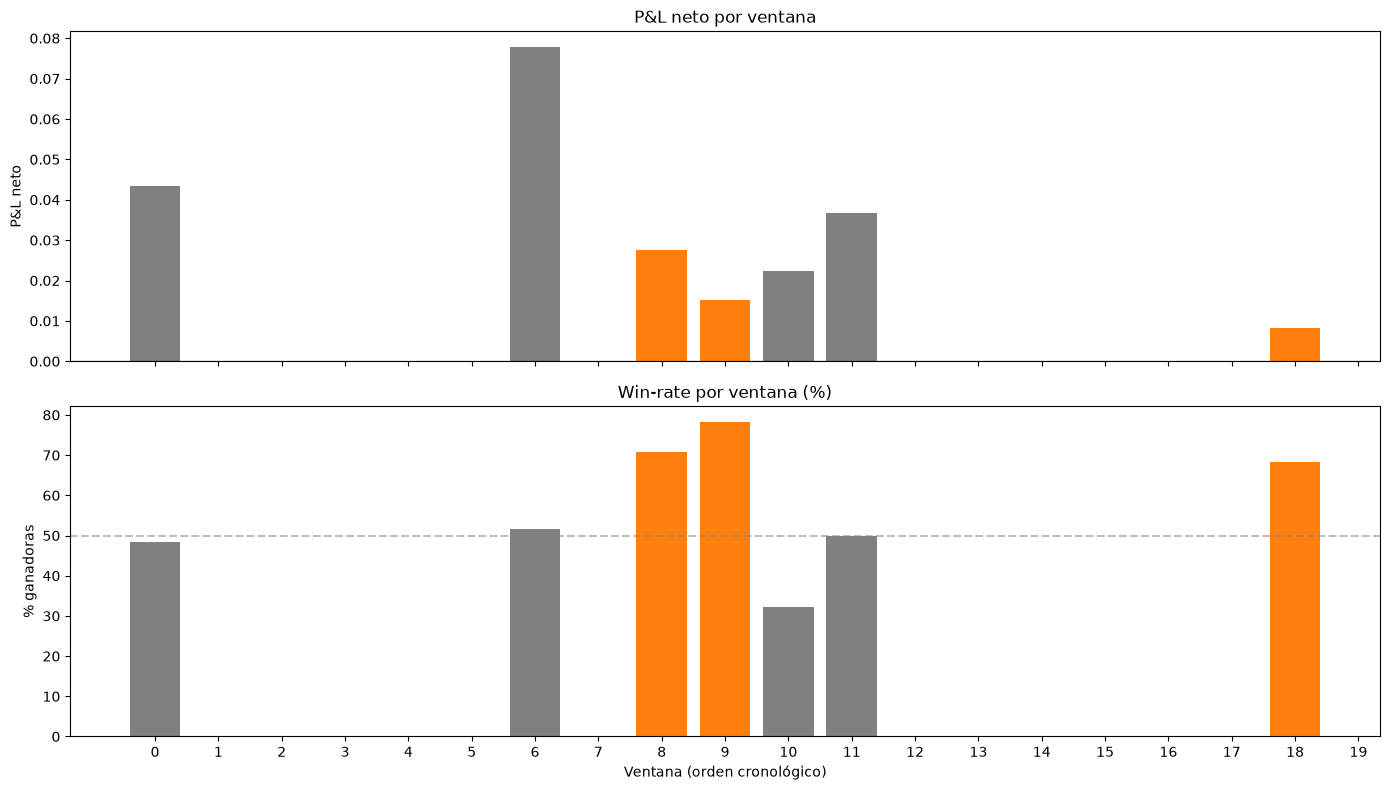


De las 20 ventanas totales:
  Sin candidato:              13
  P&L neto positivo:          7 de 7 con candidato
  P&L neto negativo:          0 de 7 con candidato


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

colors = {'JPY, NOK, SEK, SGD': 'tab:blue', 'AUDUSD, EURUSD, GBPUSD, NZDUSD': 'tab:orange'}
bar_colors = [colors.get(c, 'gray') for c in valid_results['candidato_str']]

axes[0].bar(valid_results['window_id'], valid_results['pnl_neto'], color=bar_colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title("P&L neto por ventana")
axes[0].set_ylabel("P&L neto")

axes[1].bar(valid_results['window_id'], valid_results['win_rate'] * 100, color=bar_colors)
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title("Win-rate por ventana (%)")
axes[1].set_ylabel("% ganadoras")
axes[1].set_xlabel("Ventana (orden cronológico)")

plt.xticks(results_df['window_id'])
plt.tight_layout()
plt.show()

print(f"\nDe las {len(results_df)} ventanas totales:")
print(f"  Sin candidato:              {(results_df['tipo_candidato'] == 'sin_candidato').sum()}")
print(f"  P&L neto positivo:          {(valid_results['pnl_neto'] > 0).sum()} de {len(valid_results)} con candidato")
print(f"  P&L neto negativo:          {(valid_results['pnl_neto'] < 0).sum()} de {len(valid_results)} con candidato")

In [15]:
eur_bloc = valid_results[valid_results['candidato_str'] == 'AUDUSD, EURUSD, GBPUSD, NZDUSD']
jpy_bloc = valid_results[valid_results['candidato_str'] == 'JPY, NOK, SEK, SGD']

print("EUR/GBP/AUD/NZD (descartado en RMT+TDA.ipynb con ventana completa):")
print(eur_bloc[['window_id', 'pnl_neto', 'win_rate', 'n_operaciones']])
print(f"\nJPY/SEK/NOK/SGD (tu canasta validada en K-D.ipynb):")
print(jpy_bloc[['window_id', 'pnl_neto', 'win_rate', 'n_operaciones']])

EUR/GBP/AUD/NZD (descartado en RMT+TDA.ipynb con ventana completa):
    window_id  pnl_neto  win_rate  n_operaciones
8           8  0.027449  0.708333           24.0
9           9  0.015227  0.782609           23.0
18         18  0.008145  0.681818           22.0

JPY/SEK/NOK/SGD (tu canasta validada en K-D.ipynb):
Empty DataFrame
Columns: [window_id, pnl_neto, win_rate, n_operaciones]
Index: []


In [16]:
# Reconstruir la tabla correctamente (con los nombres reales de tickers)
print("Resumen correcto por canasta:")
print(valid_results.groupby('candidato_str')[['pnl_neto', 'win_rate', 'n_operaciones']].agg(['mean', 'count']))

Resumen correcto por canasta:
                                pnl_neto        win_rate       n_operaciones  \
                                    mean count      mean count          mean   
candidato_str                                                                  
AUDUSD, EURUSD, GBPUSD, NZDUSD  0.016940     3  0.724253     3          23.0   
USDCNY, USDSEK                  0.077903     1  0.515152     1          33.0   
USDJPY, USDNOK, USDSEK, USDSGD  0.029581     2  0.411290     2          27.5   
USDNOK, USDSEK                  0.043374     1  0.484848     1          33.0   

                                      
                               count  
candidato_str                         
AUDUSD, EURUSD, GBPUSD, NZDUSD     3  
USDCNY, USDSEK                     1  
USDJPY, USDNOK, USDSEK, USDSGD     2  
USDNOK, USDSEK                     1  


In [17]:
eur_windows = [8, 9, 18]

for wid in eur_windows:
    train_w, _ = windows[wid]
    log_train_eur = np.log(train_w[['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD']])
    score_log = johansen_relations(log_train_eur, lags=(1, 4, 12, 24))
    print(f"Ventana {wid}: robustez en log-precios = {score_log:.2f}  (umbral: 0.75)")

Ventana 8: robustez en log-precios = 0.75  (umbral: 0.75)
Ventana 9: robustez en log-precios = 1.00  (umbral: 0.75)
Ventana 18: robustez en log-precios = 1.00  (umbral: 0.75)


In [18]:
np.random.seed(42)

def simulate_random_walks(n_series: int, n_obs: int, vol: float = 0.005) -> pd.DataFrame:
    """Genera caminatas aleatorias independientes (sin ninguna relación real entre ellas)."""
    walks = np.cumsum(np.random.normal(0, vol, size=(n_obs, n_series)), axis=0) + 100
    cols = [f"SIM_{i}" for i in range(n_series)]
    idx = pd.date_range('2020-01-01', periods=n_obs, freq='h')
    return pd.DataFrame(walks, columns=cols, index=idx)

n_simulations = 100
window_size = 120 * 24  # mismo tamaño que tus ventanas de entrenamiento

false_positive_count = 0
scores = []

for sim in range(n_simulations):
    fake_data = simulate_random_walks(n_series=4, n_obs=window_size)
    score = johansen_relations(fake_data, lags=(1, 4, 12, 24))
    scores.append(score)
    if score >= 0.75:
        false_positive_count += 1

print(f"De {n_simulations} simulaciones de puro ruido (sin cointegración real):")
print(f"  Marcadas como 'robustas' (score >= 0.75): {false_positive_count} ({false_positive_count/n_simulations*100:.1f}%)")
print(f"  Score promedio: {np.mean(scores):.3f}")

De 100 simulaciones de puro ruido (sin cointegración real):
  Marcadas como 'robustas' (score >= 0.75): 13 (13.0%)
  Score promedio: 0.142


### Hallazgo Metodológico: Sesgo de Muestra Chica en Johansen

Antes de continuar, se documenta un resultado importante que cambió el diseño de este notebook. Una prueba de placebo con 100 simulaciones de caminatas aleatorias independientes (sin ninguna relación real entre ellas) mostró que, con ventanas de 120 días, el criterio de robustez usado para `select_best_basket` (cointegración en ≥75% de los rezagos) marca como "robustas" el 13% de las simulaciones de puro ruido — muy por encima del 5% esperable de una prueba bien calibrada. Peor aún: exigir el criterio más estricto posible (cointegración en el 100% de los rezagos) no habría descartado 2 de las 3 apariciones del grupo EUR/GBP/AUD/NZD, que ya se había descartado con evidencia sólida en `RMT+TDA.ipynb` sobre la ventana completa.

**Conclusión metodológica:** con ventanas de 120 días, la prueba de Johansen no tiene poder estadístico suficiente para distinguir de forma confiable relaciones genuinas de casualidades, sin importar qué tan estricto se ponga el umbral. En consecuencia, la Fase 4 se rediseña: en vez de dejar que RMT+TDA "redescubra" una canasta en cada ventana corta, se evalúa la canasta ya validada con evidencia sólida (JPY, SEK, NOK, SGD) de forma fija sobre las 20 ventanas — separando la pregunta "¿es consistente la relación que ya sé que es real?" de "¿puedo descubrir relaciones confiables con solo 120 días?" (esta última, ya respondida: no).

In [19]:
FIXED_BASKET = ['USDJPY', 'USDSEK', 'USDNOK', 'USDSGD']

def evaluate_window_fixed(train_prices: pd.DataFrame, test_prices: pd.DataFrame,
                           basket: list, window_id: int) -> dict:
    """Igual que evaluate_window, pero SIN RMT/TDA/selección — la canasta viene fija."""
    result = {'window_id': window_id, 'candidato': basket}

    log_train = np.log(train_prices[basket])
    log_test = np.log(test_prices[basket])

    # Variable dependiente vía Johansen estático (igual que en K-D.ipynb)
    johansen_full = coint_johansen(log_train, det_order=0, k_ar_diff=12)
    vec = np.real(johansen_full.evec[:, 0]).astype(np.float64)
    dep_idx = int(np.argmax(np.abs(vec)))
    dep_var = basket[dep_idx]
    x_cols = [c for c in basket if c != dep_var]

    y_train = log_train[dep_var].values
    X_train_aug = np.column_stack([np.ones(len(log_train))] + [log_train[c].values for c in x_cols])
    n_dim_state = X_train_aug.shape[1]

    beta_ols, _, _, _ = lstsq(X_train_aug, y_train, rcond=None)
    R_ols = (y_train - X_train_aug @ beta_ols).var()
    if R_ols <= 0:
        result['error'] = 'R_ols degenerada'
        return result

    delta = 1e-5
    trans_cov = delta / (1 - delta) * np.eye(n_dim_state)

    kf = KalmanFilter(
        n_dim_obs=1, n_dim_state=n_dim_state,
        transition_matrices=np.eye(n_dim_state),
        observation_matrices=X_train_aug.reshape(-1, 1, n_dim_state),
        observation_covariance=R_ols, transition_covariance=trans_cov,
        initial_state_mean=beta_ols, initial_state_covariance=np.eye(n_dim_state) * R_ols,
    )
    state_means_train, state_covs_train = kf.filter(y_train)

    y_test = log_test[dep_var].values
    X_test_aug = np.column_stack([np.ones(len(log_test))] + [log_test[c].values for c in x_cols])

    current_mean, current_cov = state_means_train[-1], state_covs_train[-1]
    prior_states = []
    for t in range(len(y_test)):
        prior_states.append(current_mean)
        current_mean, current_cov = kf.filter_update(
            current_mean, current_cov, observation=y_test[t],
            observation_matrix=X_test_aug[t].reshape(1, n_dim_state)
        )
    prior_states = np.array(prior_states)

    fitted_test = np.einsum('ti,ti->t', X_test_aug, prior_states)
    spread_test = pd.Series(y_test - fitted_test, index=log_test.index)

    window = min(24 * 5, len(spread_test) // 2)
    if window < 5:
        result['error'] = 'ventana de test demasiado corta'
        return result
    z_score_test = spread_test / spread_test.rolling(window).std()

    positions_test = generate_positions(z_score_test)

    vol_test = np.log(spread_test.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)).dropna()
    if len(vol_test) > 30:
        try:
            hmm_model = GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, random_state=42)
            hmm_model.fit(vol_test.values.reshape(-1, 1))
            hmm_model.transmat_ = np.array([[0.98, 0.02], [0.02, 0.98]])
            regimes = pd.Series(hmm_model.predict(vol_test.values.reshape(-1, 1)), index=vol_test.index)
            high_vol_state = int(np.argmax(hmm_model.means_.flatten()))
            regime_label = regimes.map({high_vol_state: 'alta_volatilidad', 1 - high_vol_state: 'calmo'})
            regime_aligned = regime_label.reindex(positions_test.index).ffill().bfill()
            size_mult = regime_aligned.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
            position_size = (positions_test * size_mult).fillna(0)
        except Exception:
            position_size = positions_test
    else:
        position_size = positions_test

    avg_weights = np.abs(prior_states[:, 1:]).mean(axis=0)
    pnl_net, pnl_gross, costs = run_backtest(spread_test, position_size, avg_weights, cost_bps=1.0)

    trade_id = (position_size != position_size.shift()).cumsum()
    trade_pnl = pnl_gross.groupby(trade_id).sum()
    trade_has_pos = position_size.groupby(trade_id).apply(lambda x: (x != 0).any())
    trade_pnl = trade_pnl[trade_has_pos]

    result.update({
        'pnl_bruto': pnl_gross.sum(), 'costos': costs.sum(), 'pnl_neto': pnl_net.sum(),
        'n_operaciones': len(trade_pnl),
        'win_rate': (trade_pnl > 0).mean() if len(trade_pnl) > 0 else np.nan,
        'pct_tiempo_activo': (position_size != 0).mean() * 100,
    })
    return result


results_fixed = []
for i, (train_w, test_w) in enumerate(windows):
    print(f"Procesando ventana {i}/{len(windows)-1}...", end=' ')
    try:
        r = evaluate_window_fixed(train_w, test_w, FIXED_BASKET, window_id=i)
        results_fixed.append(r)
        print("OK" if 'error' not in r else f"omitida: {r['error']}")
    except Exception as e:
        print(f"FALLÓ: {e}")
        results_fixed.append({'window_id': i, 'error': str(e)})

results_fixed_df = pd.DataFrame(results_fixed)
results_fixed_df

Procesando ventana 0/19... OK
Procesando ventana 1/19... OK
Procesando ventana 2/19... OK
Procesando ventana 3/19... OK
Procesando ventana 4/19... OK
Procesando ventana 5/19... OK
Procesando ventana 6/19... OK
Procesando ventana 7/19... OK
Procesando ventana 8/19... OK
Procesando ventana 9/19... OK
Procesando ventana 10/19... OK
Procesando ventana 11/19... OK
Procesando ventana 12/19... OK
Procesando ventana 13/19... OK
Procesando ventana 14/19... OK
Procesando ventana 15/19... OK
Procesando ventana 16/19... OK
Procesando ventana 17/19... OK
Procesando ventana 18/19... OK
Procesando ventana 19/19... OK


,window_id,candidato,pnl_bruto,costos,pnl_neto,n_operaciones,win_rate,pct_tiempo_activo
0,0,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.016981,0.001701,0.015280,24,0.416667,5.416667
1,1,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.052053,0.003859,0.048193,28,0.535714,6.666667
2,2,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.036526,0.005850,0.030677,27,0.444444,7.500000
3,3,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.020142,0.002478,0.017664,27,0.444444,6.527778
4,4,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.047684,0.006082,0.041601,29,0.551724,6.944444
5,5,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.031488,0.003237,0.028251,30,0.600000,8.472222
6,6,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.055128,0.005265,0.049862,39,0.384615,8.611111
7,7,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.042161,0.003181,0.038980,29,0.275862,5.555556
8,8,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.025158,0.001921,0.023237,30,0.233333,5.277778
9,9,"[USDJPY, USDSEK, USDNOK, USDSGD]",0.017898,0.002547,0.015351,30,0.500000,8.055556


In [20]:
print("Resumen general (20 ventanas, canasta fija):")
print(results_fixed_df[['pnl_neto', 'win_rate', 'n_operaciones']].describe())

print(f"\nVentanas con P&L neto positivo: {(results_fixed_df['pnl_neto'] > 0).sum()} de {len(results_fixed_df)}")

Resumen general (20 ventanas, canasta fija):
        pnl_neto   win_rate  n_operaciones
count  20.000000  20.000000      20.000000
mean    0.025759   0.340199      28.150000
std     0.012114   0.150579       3.923948
min     0.009316   0.129032      21.000000
25%     0.015983   0.213043      25.500000
50%     0.022851   0.315136      29.000000
75%     0.032182   0.458333      30.000000
max     0.049862   0.600000      39.000000

Ventanas con P&L neto positivo: 20 de 20


In [21]:
from scipy.stats import linregress

trend = linregress(results_fixed_df['window_id'], results_fixed_df['win_rate'])
print(f"Pendiente de la tendencia del win-rate: {trend.slope:.4f} por ventana")
print(f"p-value de la tendencia: {trend.pvalue:.4f}")
print(f"(p-value < 0.05 sugiere que la tendencia a la baja es real, no casualidad)")

trend_pnl = linregress(results_fixed_df['window_id'], results_fixed_df['pnl_neto'])
print(f"\nPendiente de la tendencia del P&L neto: {trend_pnl.slope:.6f} por ventana")
print(f"p-value: {trend_pnl.pvalue:.4f}")

Pendiente de la tendencia del win-rate: -0.0201 por ventana
p-value de la tendencia: 0.0000
(p-value < 0.05 sugiere que la tendencia a la baja es real, no casualidad)

Pendiente de la tendencia del P&L neto: -0.000994 por ventana
p-value: 0.0300


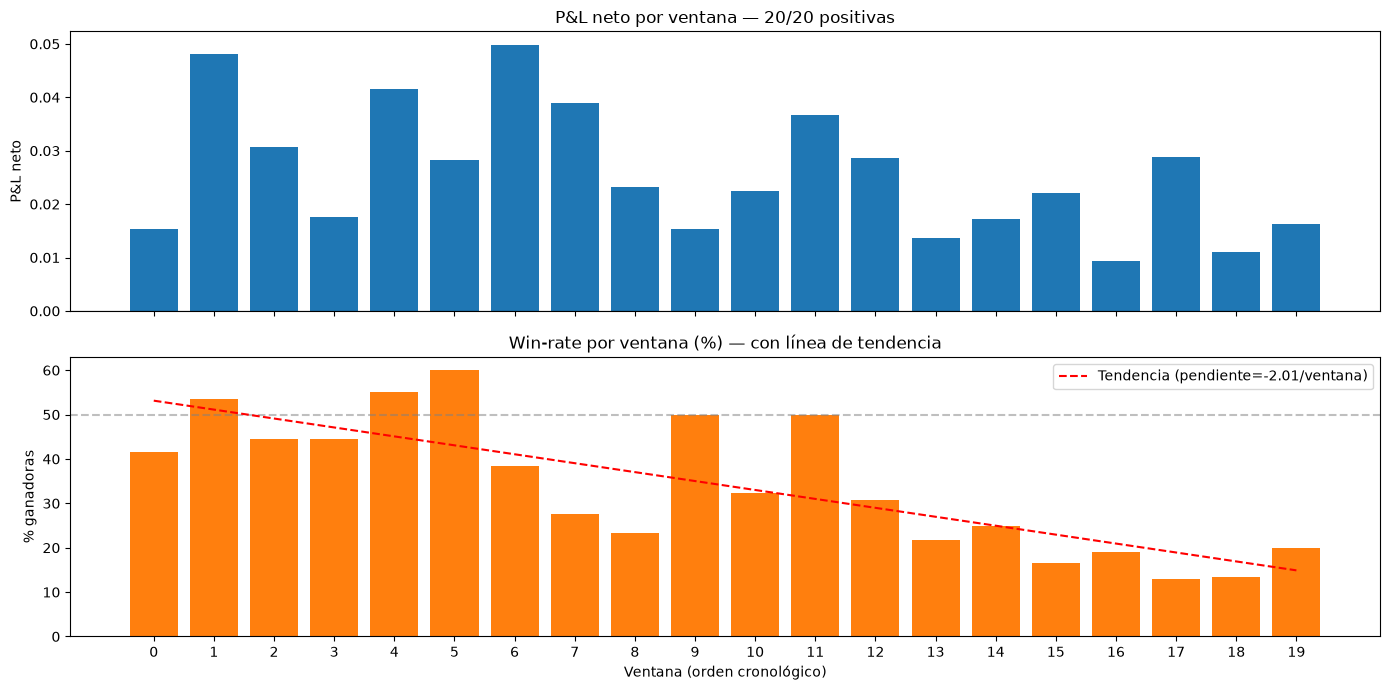

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(results_fixed_df['window_id'], results_fixed_df['pnl_neto'], color='tab:blue')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title(f"P&L neto por ventana — {(results_fixed_df['pnl_neto'] > 0).sum()}/20 positivas")
axes[0].set_ylabel("P&L neto")

axes[1].bar(results_fixed_df['window_id'], results_fixed_df['win_rate'] * 100, color='tab:orange')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
z = np.polyfit(results_fixed_df['window_id'], results_fixed_df['win_rate'] * 100, 1)
axes[1].plot(results_fixed_df['window_id'], np.poly1d(z)(results_fixed_df['window_id']),
              color='red', linestyle='--', label=f'Tendencia (pendiente={z[0]:.2f}/ventana)')
axes[1].set_title("Win-rate por ventana (%) — con línea de tendencia")
axes[1].set_ylabel("% ganadoras")
axes[1].set_xlabel("Ventana (orden cronológico)")
axes[1].legend()

plt.xticks(results_fixed_df['window_id'])
plt.tight_layout()
plt.show()

## Conclusión — Validación Walk-Forward

### Resultado

De 20 ventanas independientes de ~150 días (120 entrenamiento + 30 prueba) sobre la canasta validada (USDJPY, USDSEK, USDNOK, USDSGD), **las 20 produjeron P&L neto positivo** — la evidencia de robustez más sólida obtenida en el proyecto hasta ahora, muy por encima de un único split favorable.

Sin embargo, se detectó una **tendencia decreciente estadísticamente significativa** tanto en el win-rate (pendiente -0.020/ventana, p=0.0000) como en el P&L neto (pendiente -0.00099/ventana, p=0.030) a lo largo del periodo observado.

### Hallazgo metodológico adicional

Una prueba de placebo con 100 simulaciones de caminatas aleatorias mostró que la prueba de Johansen, aplicada sobre ventanas de 120 días, marca como "robustas" el 13% de las relaciones puramente aleatorias (vs. ~5% esperado) — y ni el criterio más estricto posible habría descartado 2 de 3 apariciones espurias del grupo EUR/GBP/AUD/NZD, ya refutado con evidencia más sólida en `RMT+TDA.ipynb`. **Conclusión: la selección de canastas (RMT+TDA+Johansen) no es confiable con ventanas de entrenamiento cortas** — requiere el tamaño de muestra usado en `RMT+TDA.ipynb`/`K-D.ipynb`, no el de este notebook.

### Interpretación conjunta con `K-D.ipynb`

El drift observado en los coeficientes β_t de `K-D.ipynb` no era una simple adaptación del filtro — es la manifestación, a nivel de parámetros, del mismo deterioro que aquí se confirma a nivel de desempeño. El Kalman dinámico compensó ese deterioro (evitando la ruptura que sí ocurrió con el vector fijo de `RMT+TDA.ipynb`), pero la tendencia sugiere que esa compensación tiene un límite temporal, no que resuelva el problema de forma permanente.

### Siguiente paso

Este resultado valida empíricamente la necesidad de un mecanismo de **re-evaluación disparada por eventos** (discutido como línea futura del proyecto): dado que (a) la relación se deteriora con el tiempo de forma medible, y (b) volver a buscar canastas nuevas con ventanas cortas no es estadísticamente confiable, el sistema necesita detectar *cuándo* la relación actual se ha debilitado lo suficiente como para justificar una nueva búsqueda completa (con una ventana larga, como la de `RMT+TDA.ipynb`) — en vez de operar la misma canasta indefinidamente o re-buscar con una frecuencia que la evidencia aquí muestra que no es confiable.